# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Вариант 2: задания 1 и 2 на наборе данных MNIST

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

Вариант 4: задания 1 и 3 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [30]:
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

digits = load_digits()

X = digits.data
y = digits.target

print(X.shape)
print(y.shape)

Clear previously loaded data.
(1797, 64)
(1797,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



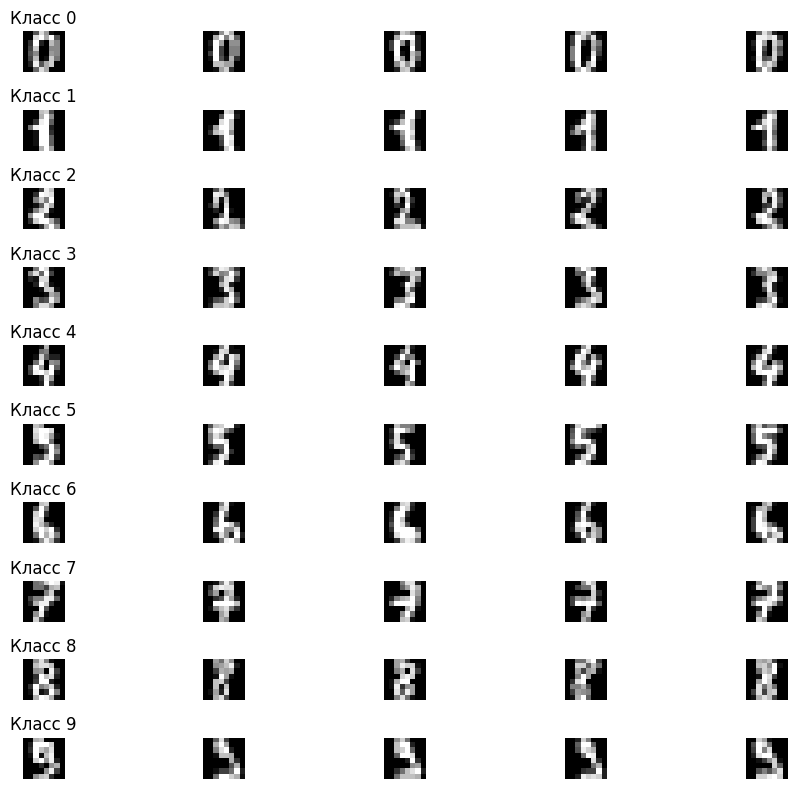

In [29]:
fig, axes = plt.subplots(10, 5)

for i in range(10):
    idxs = np.where(digits.target == i)[0]
    for j in range(5):
        axes[i, j].imshow(digits.images[idxs[j]], cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(f"Класс {i}")

plt.tight_layout()
plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (1437, 64)
Training labels shape:  (1437,)
Test data shape:  (360, 64)
Test labels shape:  (360,)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [7]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [8]:
y_test_pred = classifier.predict(X_test, k=1, num_loops=0)

1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


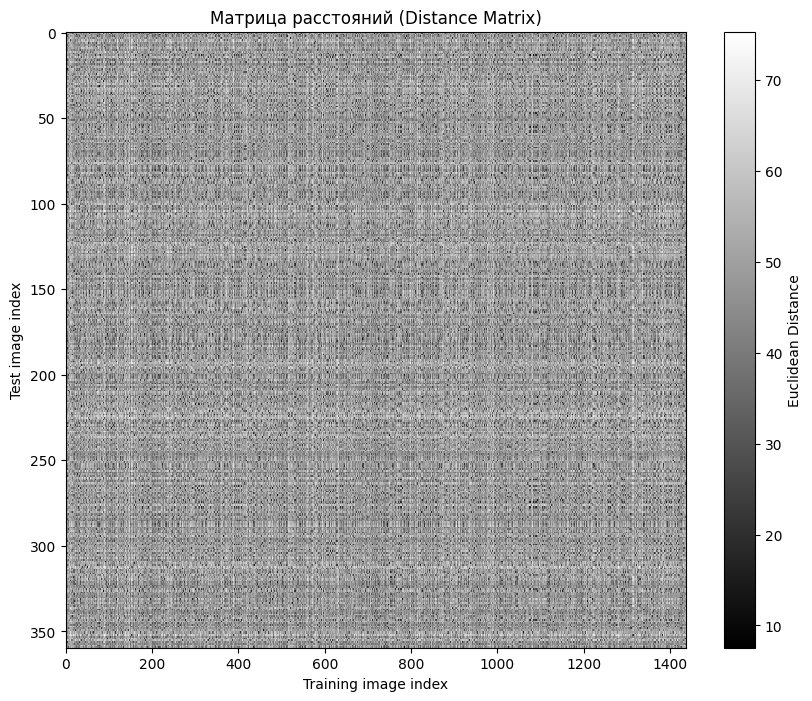

In [9]:
dists = classifier.compute_distances_no_loops(X_test)

plt.imshow(dists, interpolation='none', aspect='auto')
plt.colorbar(label='Euclidean Distance')
plt.xlabel('Training image index')
plt.ylabel('Test image index')
plt.title('Матрица расстояний (Distance Matrix)')
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [10]:
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / len(y_test)

print(f'Правильно классифицировано {num_correct} из {len(y_test)} изображений.')
print(f'Точность (Accuracy): {accuracy:.4f}')

Правильно классифицировано 352 из 360 изображений.
Точность (Accuracy): 0.9778


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

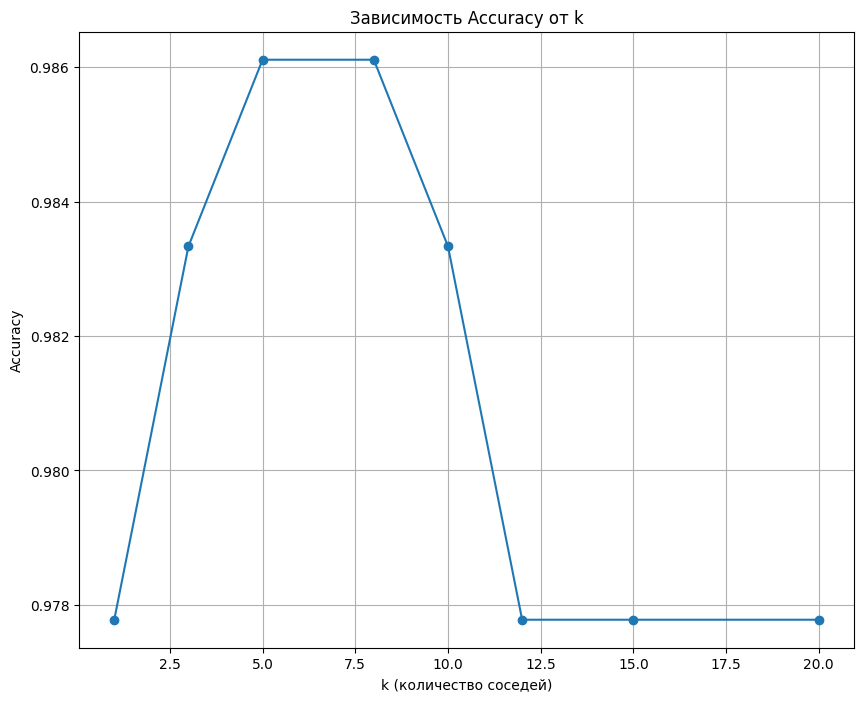

In [11]:
k_choices = [1, 3, 5, 8, 10, 12, 15, 20]
k_to_accuracies = []

for k in k_choices:
    y_test_pred = classifier.predict(X_test, k=k)
    accuracy = np.mean(y_test_pred == y_test)
    k_to_accuracies.append(accuracy)

plt.plot(k_choices, k_to_accuracies, marker='o')
plt.title('Зависимость Accuracy от k')
plt.xlabel('k (количество соседей)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [34]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20]

X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for fold in range(num_folds):
        X_tr = np.concatenate([X_train_folds[i] for i in range(num_folds) if i != fold])
        y_tr = np.concatenate([y_train_folds[i] for i in range(num_folds) if i != fold])

        X_val = X_train_folds[fold]
        y_val = y_train_folds[fold]

        knn = KNearestNeighbor()
        knn.train(X_tr, y_tr)
        y_val_pred = knn.predict(X_val, k=k)

        accuracy = np.mean(y_val_pred == y_val)
        k_to_accuracies[k].append(accuracy)

for k in k_choices:
    accuracies = k_to_accuracies[k]


print('Результаты кросс-валидации:')

for k in sorted(k_to_accuracies.keys()):
    accuracies = k_to_accuracies[k]
    mean_acc = np.mean(accuracies)

    print(f'k = {k:2d} | Mean Accuracy: {mean_acc:.4f}')

accuracies_mean = [np.mean(k_to_accuracies[k]) for k in k_choices]
best_k = k_choices[np.argmax(accuracies_mean)]

print(f'Лучшее значение k по итогам кросс-валидации: {best_k}')

Результаты кросс-валидации:
k =  1 | Mean Accuracy: 0.9847
k =  3 | Mean Accuracy: 0.9833
k =  5 | Mean Accuracy: 0.9812
k =  8 | Mean Accuracy: 0.9771
k = 10 | Mean Accuracy: 0.9736
k = 12 | Mean Accuracy: 0.9736
k = 15 | Mean Accuracy: 0.9722
k = 20 | Mean Accuracy: 0.9610
Лучшее значение k по итогам кросс-валидации: 1



1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [13]:
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)
final_accuracy = np.mean(y_test_pred == y_test)
print(f'Финальная точность на тестовой выборке с k={best_k}: {final_accuracy:.4f}')

Финальная точность на тестовой выборке с k=1: 0.9778


1.11 Сделайте выводы по результатам 1 части задания.

Алгоритм kNN продемонстрировал исключительную эффективность на наборе данных digits, достигнув пиковой точности 98.47% при $k=1$, что свидетельствует о высокой локальной плотности и четкой разделимости признаков внутри классов. Постепенное снижение метрики при увеличении числа соседей указывает на то, что для данного датасета расширение области голосования вносит избыточное сглаживание, которое скорее мешает, чем помогает классификации. Итоговый результат на тестовой выборке в 97.78% подтверждает отличную обобщающую способность модели и её устойчивость к новым данным.

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [14]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25
)

num_dev = 100
mask = np.random.choice(X_train.shape[0], num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1077, 64)
(360, 64)
(360, 64)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[0.00000000e+00 3.13834726e-01 5.27576602e+00 1.18105850e+01
 1.16787372e+01 5.61745590e+00 1.37511606e+00 1.59702878e-01
 4.64252553e-03 2.07335190e+00]


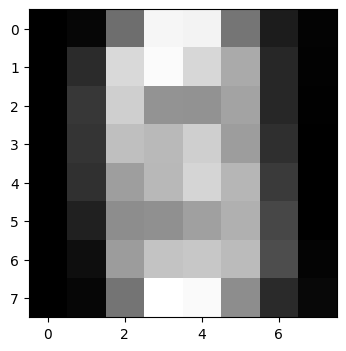

(1077, 65) (360, 65) (360, 65)


In [15]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((8,8)), cmap="gray")
plt.show()

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])


print(X_train.shape, X_val.shape, X_test.shape)

2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [16]:
from scripts.classifiers.linear_svm import svm_loss_naive, svm_loss_vectorized
import time


W = np.random.randn(64, 10) * 0.0001

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

loss: 9.011068



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [17]:
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 1.470000 analytic: 1.470000, relative error: 1.385611e-10
numerical: -0.770000 analytic: -0.770000, relative error: 3.969155e-11
numerical: 7.380000 analytic: 7.380000, relative error: 8.629051e-14
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: -0.090000 analytic: -0.090000, relative error: 7.814081e-11
numerical: 0.240000 analytic: 0.240000, relative error: 7.814079e-11
numerical: -0.090000 analytic: -0.090000, relative error: 7.814081e-11
numerical: -3.590000 analytic: -3.590000, relative error: 4.327025e-12
numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: -0.850000 analytic: -0.850000, relative error: 1.482576e-10
numerical: 1.416040 analytic: 1.416040, relative error: 1.602635e-11
numerical: -0.547004 analytic: -0.547004, relative error: 5.421431e-11
numerical: 0.292256 analytic: 0.292256, relative error: 5.493368e-11
numerical: 4.110528 analytic: 4.110528, relative error: 1.123002e-11
numerical: 7.296011 analytic: 7.296011, 

C:\Users\User\.ipython\AIT_labs\lab_1-2\scripts\gradient_check.py:126: RuntimeWarning: invalid value encountered in scalar divide
  rel_error = (abs(grad_numerical - grad_analytic) /


2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [18]:
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.002965s
Vectorized loss and gradient: computed in 0.000000s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [19]:
from scripts.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 24.297996
iteration 100 / 1500: loss 14.587779
iteration 200 / 1500: loss 11.017452
iteration 300 / 1500: loss 9.707592
iteration 400 / 1500: loss 9.224787
iteration 500 / 1500: loss 9.053689
iteration 600 / 1500: loss 8.987375
iteration 700 / 1500: loss 8.964624
iteration 800 / 1500: loss 8.959141
iteration 900 / 1500: loss 8.951229
iteration 1000 / 1500: loss 8.949845
iteration 1100 / 1500: loss 8.951788
iteration 1200 / 1500: loss 8.943956
iteration 1300 / 1500: loss 8.947989
iteration 1400 / 1500: loss 8.949872
That took 0.213556s


In [20]:
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.875580
validation accuracy: 0.861111


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [24]:
results = {}
best_val = -1
best_svm = None

learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

for lr in learning_rates:
    for reg in regularization_strengths:
        svm = LinearSVM()

        svm.train(X_train, y_train, learning_rate=lr, reg=reg,
                  num_iters=1500, verbose=False)

        y_train_pred = svm.predict(X_train)
        y_val_pred = svm.predict(X_val)

        train_accuracy = np.mean(y_train == y_train_pred)
        val_accuracy = np.mean(y_val == y_val_pred)

        results[(lr, reg)] = (train_accuracy, val_accuracy)

        if val_accuracy > best_val:
            best_val = val_accuracy
            best_svm = svm

for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.876509 val accuracy: 0.855556
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.872795 val accuracy: 0.866667
lr 5.000000e-05 reg 2.500000e+04 train accuracy: 0.038997 val accuracy: 0.050000
lr 5.000000e-05 reg 5.000000e+04 train accuracy: 0.108635 val accuracy: 0.094444
best validation accuracy achieved during cross-validation: 0.866667


2.9 Сделайте выводы по второй части задания

В ходе работы была подтверждена корректность базовой модели: стартовое значение потерь составило около 9.0, что соответствует математическому ожиданию для классификации на десять категорий. Проверка производных через сравнение аналитического и численного методов показала минимальную относительную погрешность, гарантируя точность вычисленных градиентов. Тестирование производительности выявило, что векторизованный подход к расчету функции потерь и градиента идентичен наивному по результатам, но значительно превосходит его в скорости выполнения за счет оптимизации матричных операций.

При сравнении с алгоритмом kNN стало очевидно фундаментальное различие в эффективности: SVM требует сложного этапа обучения с подбором параметров, но обеспечивает практически мгновенную классификацию на этапе тестирования. Это делает линейный классификатор гораздо более пригодным для масштабирования, так как итоговая модель представляет собой лишь компактную матрицу весов, а не всю базу данных. В конечном итоге, метод опорных векторов продемонстрировал себя как более гибкий и производительный инструмент для обработки крупных наборов данных.